# Iterative Prediction — Exploration & Sanity Check

**Goals:**
1. Define a unified iterative prediction interface (baseline + ML models).
2. Sanity check: baseline iterative == baseline linear projection (must match).
3. Run all 5 joblib models iteratively and compare their outputs.
4. Confirm that `dist_t2` (current bank position) updates correctly between steps.

**Key insight:**  
For the baseline model (constant velocity), iterative and linear give identical results — this is the sanity check.  
For ML models (LightGBM, Ridge), velocity can change year-to-year as `dist_t2` updates, so iterative matters.

In [1]:
import os
import sys
from pathlib import Path

_cwd = Path.cwd()
if (_cwd / 'src').exists():
    _backend = _cwd
elif (_cwd.parent / 'src').exists():
    _backend = _cwd.parent
elif (_cwd.parent.parent / 'src').exists():
    _backend = _cwd.parent.parent
else:
    _backend = _cwd
os.chdir(_backend)
sys.path.insert(0, str(_backend))
print('cwd:', os.getcwd())

cwd: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/notebooks/04_model/20260313_pipeline_building


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.paths as PATHS
import src.model.baseline_model as BM
import src.data.config as DATA_CONFIG
import src.constants as CONST
from src.model.export_utils import load_model_bundle, predict as bundle_predict
from src.model.feature_shifter import FeatureShifter, FeatureShiftConfig

DATA_DIR = PATHS.DATA_DIR

## Config

Set prediction range and step here. These drive all cells below.

In [3]:
START_YEAR = 2026
END_YEAR   = 2035   # default: START_YEAR + 9
STEP       = 1      # 1 = every year; 3 = 2026, 2029, 2032, 2035; etc.

PREDICTION_YEARS = list(range(START_YEAR, END_YEAR + 1, STEP))
print(f'Prediction years ({len(PREDICTION_YEARS)}): {PREDICTION_YEARS}')

Prediction years (10): [2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035]


## 1. Load data

In [4]:
# region_features: ML model input (one row per location, features like v_train, dist_t2, ...)
features_df = pd.read_parquet(DATA_DIR / '02_processed/erosion/region_features.parquet')
print(f'region_features: {len(features_df):,} locations, columns: {list(features_df.columns)}')

region_features: 7,444 locations, columns: ['v_train', 'v_test', 'dist_t1', 'dist_t2', 'dist_t3', 'train_span_yr', 'test_span_yr', 'is_nvo', 'river', 'river_enc', 'vegetation_class', 'vegetation_class_enc', 'land_use', 'land_use_enc', 'erosion_vol_rate_t1', 'soil_group', 'soil_group_enc', 'n_events_t1', 'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1', 'n_events_t2', 'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2', 'bend_exposure_n5', 'bend_exposure_n8', 'split', 'cluster']


In [5]:
# region_inference_only: last observed dist + year + velocity per location
# This covers locations outside the train/test split that still need predictions
inference_df = pd.read_parquet(DATA_DIR / '02_processed/erosion/region_inference_only.parquet')
print(f'region_inference_only: {len(inference_df):,} locations')
print(inference_df.head(3))

region_inference_only: 1,082 locations
                       cluster  n_timestamps  last_year   last_dist    v_last
location_id                                                                  
ijssel1_l_0000_0010    ijssel1             2       2025  162.083333 -0.062500
ijssel1_l_0340_0350    ijssel1             2       2025   60.672558 -0.070389
ijssel1_l_10350_10360  ijssel1             1       2017  133.446244       NaN


In [6]:
# Load t3 (most recent observation year per location) from region_split
region_split = pd.read_parquet(DATA_DIR / '02_processed/erosion/region_split.parquet')

# Build a unified starting-point lookup: {loc_id: (last_dist, last_year, v_hist)}
# Priority: features_df (dist_t3, t3 year, v_train), then inference_df (last_dist, last_year, v_last)
start_points = {}

for loc_id, row in features_df.iterrows():
    t3_year = int(region_split.loc[loc_id, 't3']) if loc_id in region_split.index else 2025
    start_points[loc_id] = {
        'last_dist': row['dist_t3'],
        'last_year': t3_year,
        'v_hist': row['v_train'],
    }

for loc_id, row in inference_df.iterrows():
    if loc_id not in start_points:
        start_points[loc_id] = {
            'last_dist': row['last_dist'],
            'last_year': int(row['last_year']),
            'v_hist': row['v_last'],
        }

print(f'Total locations with starting point: {len(start_points):,}')
last_years = pd.Series({k: v['last_year'] for k, v in start_points.items()})
print('last_year distribution:', last_years.value_counts().to_dict())

Total locations with starting point: 8,526
last_year distribution: {2024: 5466, 2025: 2135, 2020: 727, 2021: 78, 2022: 56, 2016: 30, 2015: 28, 2017: 6}


## 2. Load models

In [7]:
# Baseline model (pkl): {location_id: mean_velocity}
MODEL_PKL = DATA_DIR / '04_model_outputs/20260217/baseline_model_full_dataset.pkl'
baseline = BM.BaselineErosionModel.load_model(MODEL_PKL)
model_velocities = baseline.model   # dict {loc_id: velocity}
print(f'Baseline model: {len(model_velocities):,} locations')

Baseline model: 10,484 locations


In [8]:
# ML models (joblib bundle)
BUNDLE_DIR = DATA_DIR / '04_model_outputs/20260312'
bundle = load_model_bundle(BUNDLE_DIR)
config = bundle['config']
ML_MODELS = ['ols', 'ridge_num', 'ridge_cat', 'lgb']
print('Bundle loaded. Available models:', ML_MODELS)
print('Target:', config['TARGET'])
print('LGB features:', config['FEATS_LGB'])

Bundle loaded. Available models: ['ols', 'ridge_num', 'ridge_cat', 'lgb']
Target: v_test
LGB features: ['v_train', 'dist_t2', 'train_span_yr', 'test_span_yr', 'erosion_vol_rate_t1', 'n_events_t1', 'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1', 'n_events_t2', 'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2', 'bend_exposure_n5', 'bend_exposure_n8', 'is_nvo', 'river_enc', 'vegetation_class_enc', 'soil_group_enc', 'land_use_enc']


## 3. Iterative prediction functions

### 3a. Baseline (constant velocity)

For the baseline model, velocity is constant per location.  
- **Pre-step**: advance from `last_year` to `START_YEAR` using historical velocity.
- **Main loop**: for each prediction year, add `velocity × step` to the running dist.

Since velocity is constant, this is mathematically equivalent to the linear formula:  
`dist(y) = last_dist + velocity × (y - last_year)`.

In [9]:
def predict_iterative_baseline(
    model_velocities: dict,
    start_points: dict,
    start_year: int = START_YEAR,
    end_year: int = END_YEAR,
    step: int = STEP,
) -> pd.DataFrame:
    """
    Iterative prediction using the baseline model (constant velocity per location).

    Each year: dist += velocity * step.
    Pre-step extrapolates from last_year to start_year before the main loop.
    """
    prediction_years = range(start_year, end_year + 1, step)
    rows = []

    for loc_id, velocity in model_velocities.items():
        if loc_id not in start_points:
            continue
        sp = start_points[loc_id]
        last_dist, last_year = sp['last_dist'], sp['last_year']

        # Pre-step: advance from last_year to start_year
        current_dist = (
            last_dist + velocity * (start_year - last_year)
            if last_year < start_year else last_dist
        )

        for year in prediction_years:
            rows.append({
                'location_id': loc_id,
                'year': year,
                'predicted_dist_m': current_dist,
                'velocity_m_per_yr': velocity,
            })
            current_dist += velocity * step

    return pd.DataFrame(rows)

### 3b. ML models — iterative prediction with FeatureShifter

`FeatureShifter` manages the rolling feature state between steps.  
With `rolling=True` (default), at every step it applies:

| Feature | Update |
|---|---|
| `dist_t2` | ← previous predicted dist |
| `v_train` | ← previous predicted velocity → drives mean-reversion |
| `train_span_yr` | ← previous `test_span_yr` |
| `test_span_yr` | ← `step` |
| `n_events_t1`, `max_rise_rate_t1`, `drawdown_index_t1`, `flood_days_t1` | ← shift from t2 |
| `n_events_t2`, … | hold (repeat last known — best forecast without future hydrology) |
| bend, soil, vegetation, … | hold (static) |

With `rolling=False`, only `dist_t2` updates (previous behaviour).

In [10]:
def predict_iterative_ml(
    bundle: dict,
    features_df: pd.DataFrame,
    start_points: dict,
    model_name: str,
    start_year: int = START_YEAR,
    end_year: int = END_YEAR,
    step: int = STEP,
    rolling: bool = True,
    shift_config: FeatureShiftConfig = None,
) -> pd.DataFrame:
    """
    Iterative prediction using an ML model from the bundle.

    Each year:
      1. Predict velocity using the current feature state.
      2. Advance dist by velocity * step.
      3. Update the feature state for the next iteration.

    Args:
        rolling: If True (default), use FeatureShifter — updates v_train, spans,
                 and hydrology in addition to dist_t2.  If False, only dist_t2
                 is updated (previous behaviour, useful as a comparison baseline).
        shift_config: Override the default FeatureShiftConfig (e.g. to use
                      different column names).  Ignored when rolling=False.
    """
    prediction_years = list(range(start_year, end_year + 1, step))
    locs = [loc for loc in features_df.index if loc in start_points]

    if rolling:
        config = shift_config or FeatureShiftConfig()
        shifter = FeatureShifter(features_df.loc[locs], config=config)
        shifter.initialize(start_points, start_year)
    else:
        # Legacy mode: only dist_t2 updates
        dist_feature = (shift_config or FeatureShiftConfig()).dist_feature
        features_iter = features_df.loc[locs].copy()
        for loc_id in locs:
            sp = start_points[loc_id]
            last_dist, last_year = sp['last_dist'], sp['last_year']
            v_hist = sp.get('v_hist') or 0.0
            dist_at_start = (
                last_dist + v_hist * (start_year - last_year)
                if last_year < start_year else last_dist
            )
            features_iter.loc[loc_id, dist_feature] = dist_at_start

    rows = []
    for year in prediction_years:
        feats = shifter.get(locs) if rolling else features_iter
        velocities = bundle_predict(bundle, feats, model_name)
        dist_col = (shift_config or FeatureShiftConfig()).dist_feature
        new_dists = feats[dist_col].values + np.asarray(velocities) * step

        for i, loc_id in enumerate(locs):
            rows.append({
                'location_id': loc_id,
                'year': year,
                'predicted_dist_m': float(new_dists[i]),
                'velocity_m_per_yr': float(velocities[i]),
                'model': model_name,
            })

        if rolling:
            shifter.step(locs, velocities=velocities, dists=new_dists, step_size=step)
        else:
            for i, loc_id in enumerate(locs):
                features_iter.loc[loc_id, dist_col] = float(new_dists[i])

    return pd.DataFrame(rows)

## 4. Sanity check: baseline iterative == linear projection

For constant velocity: `dist_iterative(y) = last_dist + v × (y - last_year)` exactly.  
If this assertion fails, there is a bug.

In [11]:
# --- Run baseline iterative ---
df_iterative = predict_iterative_baseline(model_velocities, start_points)
print(f'Iterative: {len(df_iterative):,} rows, {df_iterative["location_id"].nunique():,} locations')
df_iterative.head()

Iterative: 85,260 rows, 8,526 locations


,location_id,year,predicted_dist_m,velocity_m_per_yr
0,ijssel1_l_0000_0010,2026,162.208333,0.125
1,ijssel1_l_0000_0010,2027,162.333333,0.125
2,ijssel1_l_0000_0010,2028,162.458333,0.125
3,ijssel1_l_0000_0010,2029,162.583333,0.125
4,ijssel1_l_0000_0010,2030,162.708333,0.125


In [12]:
# --- Run baseline linear (current pipeline approach) ---
REFERENCE_YEAR = START_YEAR - 1  # = 2025 by default

rows_linear = []
for loc_id, velocity in model_velocities.items():
    if loc_id not in start_points:
        continue
    sp = start_points[loc_id]
    last_dist, last_year = sp['last_dist'], sp['last_year']

    # Extrapolate to reference year
    dist_at_ref = (
        last_dist + velocity * (REFERENCE_YEAR - last_year)
        if last_year < REFERENCE_YEAR else last_dist
    )
    for year in PREDICTION_YEARS:
        rows_linear.append({
            'location_id': loc_id,
            'year': year,
            'predicted_dist_m': dist_at_ref + velocity * (year - REFERENCE_YEAR),
            'velocity_m_per_yr': velocity,
        })

df_linear = pd.DataFrame(rows_linear)
print(f'Linear: {len(df_linear):,} rows, {df_linear["location_id"].nunique():,} locations')

Linear: 85,260 rows, 8,526 locations


In [13]:
# --- Compare: should be identical (within floating point) ---
merged = df_iterative.merge(
    df_linear.rename(columns={'predicted_dist_m': 'dist_linear'}),
    on=['location_id', 'year'],
)
merged['diff'] = (merged['predicted_dist_m'] - merged['dist_linear']).abs()

max_diff = merged['diff'].max()
print(f'Max absolute difference (iterative vs linear): {max_diff:.2e}')
assert max_diff < 1e-9, f'SANITY CHECK FAILED: max diff = {max_diff}'
print('✓ Sanity check passed: baseline iterative == linear projection')

Max absolute difference (iterative vs linear): 3.41e-13
✓ Sanity check passed: baseline iterative == linear projection


## 5. ML model iterative predictions

Run all 4 ML models iteratively. Each year, `dist_t2` is updated to the previous predicted position.  
For `ols` (v_train only feature), velocity is constant — result should be similar to baseline.

In [14]:
results = {'baseline': df_iterative.assign(model='baseline')}

for model_name in ML_MODELS:
    print(f'Running {model_name}...')
    df_ml = predict_iterative_ml(bundle, features_df, start_points, model_name)
    results[model_name] = df_ml
    print(f'  {len(df_ml):,} rows, {df_ml["location_id"].nunique():,} locations')

print('Done.')

Running ols...
  74,440 rows, 7,444 locations
Running ridge_num...
  74,440 rows, 7,444 locations
Running ridge_cat...
  74,440 rows, 7,444 locations
Running lgb...
  74,440 rows, 7,444 locations
Done.


In [15]:
# Summary: predicted velocity distribution per model
summary_rows = []
for name, df in results.items():
    first_year = df[df['year'] == START_YEAR]
    summary_rows.append({
        'model': name,
        'n_locations': df['location_id'].nunique(),
        'median_velocity': first_year['velocity_m_per_yr'].median(),
        'mean_velocity': first_year['velocity_m_per_yr'].mean(),
        'p90_velocity': first_year['velocity_m_per_yr'].quantile(0.9),
    })

pd.DataFrame(summary_rows).set_index('model').round(3)

,n_locations,median_velocity,mean_velocity,p90_velocity
model,,,,
baseline,8526,0.017,0.198,1.020
ols,7444,0.192,0.157,0.422
ridge_num,7444,0.190,0.155,0.563
ridge_cat,7444,0.168,0.154,0.655
lgb,7444,0.073,0.149,0.920


## 6. Visual comparison: predicted dist over time (sample locations)

In [16]:
# Pick a few representative locations that all models have predictions for
common_locs = set(results['baseline']['location_id'])
for df in results.values():
    common_locs &= set(df['location_id'])

# Sample across clusters
from src.erosion.centerline_utils import pick_across_clusters
sample_locs = pick_across_clusters(sorted(common_locs), n=4)
print('Sample locations:', sample_locs)

Sample locations: ['nederrijn_l_0020_0030', 'ijssel1_l_0010_0020', 'maas1_l_0671_0680', 'nederrijn_l_0090_0100']


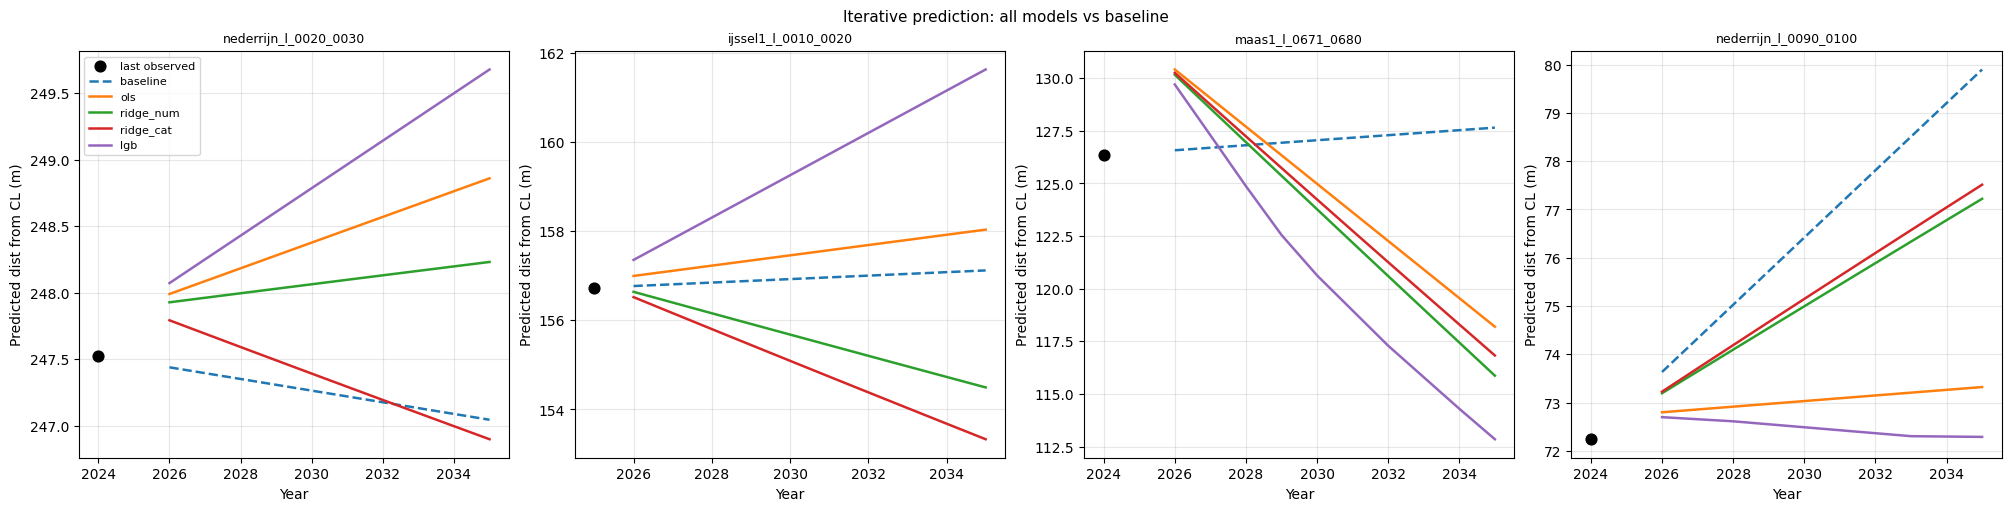

In [17]:
MODEL_COLORS = {
    'baseline':   '#1f77b4',
    'ols':        '#ff7f0e',
    'ridge_num':  '#2ca02c',
    'ridge_cat':  '#d62728',
    'lgb':        '#9467bd',
}

fig, axes = plt.subplots(1, len(sample_locs), figsize=(5 * len(sample_locs), 5), constrained_layout=True)
if len(sample_locs) == 1:
    axes = [axes]

for ax, loc_id in zip(axes, sample_locs):
    # Historical starting point
    sp = start_points.get(loc_id, {})
    if sp:
        ax.scatter([sp['last_year']], [sp['last_dist']], color='black', zorder=5,
                   label='last observed', s=60)

    for name, df in results.items():
        sub = df[df['location_id'] == loc_id].sort_values('year')
        if sub.empty:
            continue
        ax.plot(sub['year'], sub['predicted_dist_m'],
                label=name, color=MODEL_COLORS.get(name), lw=1.8,
                ls='--' if name == 'baseline' else '-')

    ax.set_title(loc_id, fontsize=9)
    ax.set_xlabel('Year')
    ax.set_ylabel('Predicted dist from CL (m)')
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8, loc='best')
fig.suptitle('Iterative prediction: all models vs baseline', fontsize=11)
plt.show()

## 7. Check: does dist_t2 update cause velocity drift in ML models?

For the LGB model, plot predicted velocity over time for the same sample locations.  
Baseline velocity is constant; LGB velocity should vary if dist_t2 is a meaningful predictor.

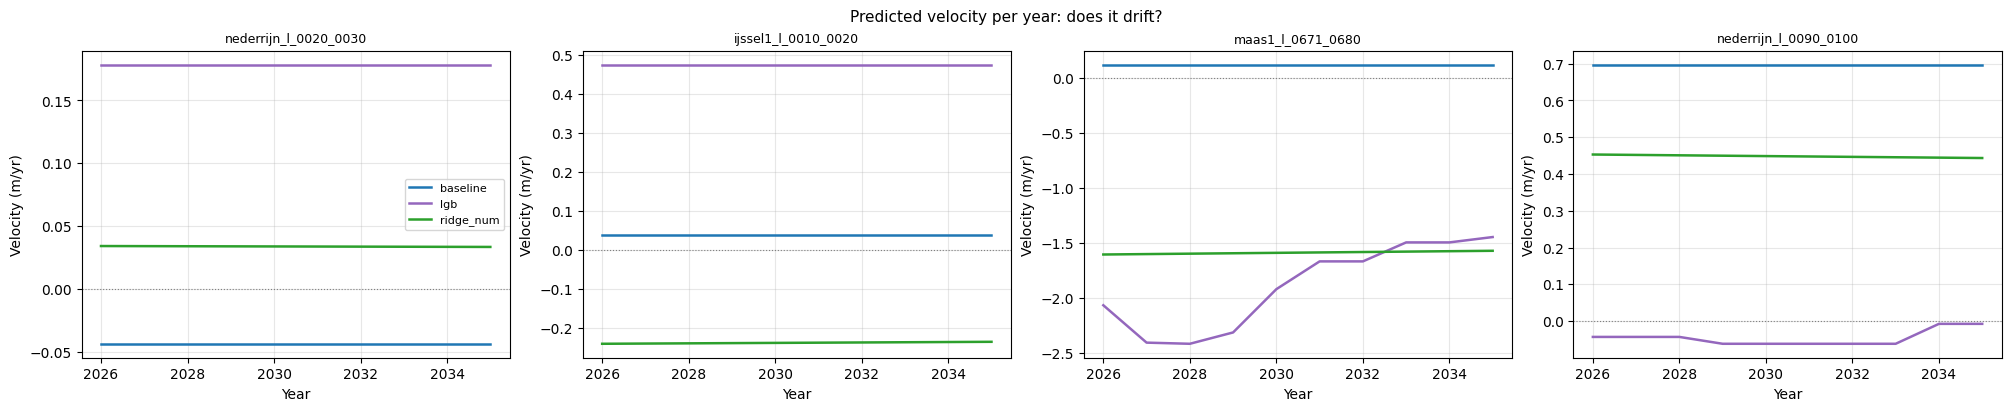

In [18]:
fig, axes = plt.subplots(1, len(sample_locs), figsize=(5 * len(sample_locs), 4), constrained_layout=True)
if len(sample_locs) == 1:
    axes = [axes]

for ax, loc_id in zip(axes, sample_locs):
    for name in ['baseline', 'lgb', 'ridge_num']:
        df = results.get(name)
        if df is None:
            continue
        sub = df[df['location_id'] == loc_id].sort_values('year')
        if sub.empty:
            continue
        ax.plot(sub['year'], sub['velocity_m_per_yr'],
                label=name, color=MODEL_COLORS.get(name), lw=1.8)

    ax.axhline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(loc_id, fontsize=9)
    ax.set_xlabel('Year')
    ax.set_ylabel('Velocity (m/yr)')
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8)
fig.suptitle('Predicted velocity per year: does it drift?', fontsize=11)
plt.show()

---
## 8. Rolling window comparison: `rolling=False` vs `rolling=True`

Run LGB with both modes and compare:
- **rolling=False** — only `dist_t2` updates (velocity is near-constant, looks linear)
- **rolling=True** — full FeatureShifter: `v_train`, spans, and hydrology all shift

Expect `rolling=True` to show genuine year-over-year velocity drift driven by mean-reversion in `v_train`.

In [ ]:
print('Running LGB rolling=False...')
df_lgb_no_roll = predict_iterative_ml(
    bundle, features_df, start_points, 'lgb', rolling=False
)
print('Running LGB rolling=True...')
df_lgb_rolling = predict_iterative_ml(
    bundle, features_df, start_points, 'lgb', rolling=True
)
print('Done.')
print(f'  rolling=False: {len(df_lgb_no_roll):,} rows')
print(f'  rolling=True:  {len(df_lgb_rolling):,} rows')

In [ ]:
# --- Velocity trajectory: does rolling=True show mean-reversion? ---
fig, axes = plt.subplots(2, len(sample_locs),
                         figsize=(5 * len(sample_locs), 8),
                         constrained_layout=True)

for col, loc_id in enumerate(sample_locs):
    for row_idx, (label, df, color) in enumerate([
        ('dist (m from CL)', None, None),
    ]):
        pass  # placeholder — real plots below

for col, loc_id in enumerate(sample_locs):
    sp = start_points.get(loc_id, {})

    for df, label, color, ls in [
        (df_lgb_no_roll, 'rolling=False', '#e74c3c', '--'),
        (df_lgb_rolling, 'rolling=True',  '#2ecc71', '-'),
        (results['baseline'], 'baseline',   '#3498db', ':'),
    ]:
        sub = df[df['location_id'] == loc_id].sort_values('year')
        if sub.empty:
            continue

        # Top row: dist trajectory
        axes[0, col].plot(sub['year'], sub['predicted_dist_m'],
                          label=label, color=color, lw=2, ls=ls)
        # Bottom row: velocity trajectory
        axes[1, col].plot(sub['year'], sub['velocity_m_per_yr'],
                          label=label, color=color, lw=2, ls=ls)

    if sp:
        axes[0, col].scatter([sp['last_year']], [sp['last_dist']],
                             color='black', zorder=5, s=60)

    axes[0, col].set_title(loc_id, fontsize=9)
    axes[0, col].set_ylabel('Predicted dist (m)')
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].axhline(0, color='grey', lw=0.8, ls=':')
    axes[1, col].set_xlabel('Year')
    axes[1, col].set_ylabel('Velocity (m/yr)')
    axes[1, col].grid(True, alpha=0.3)

axes[0, 0].legend(fontsize=8)
fig.suptitle('LGB: rolling=False (only dist_t2) vs rolling=True (full FeatureShifter)',
             fontsize=11)
plt.show()

In [ ]:
# --- Aggregate: how much does rolling affect velocity over time? ---
def velocity_by_year(df, label):
    grp = df.groupby('year')['velocity_m_per_yr']
    return pd.DataFrame({
        'year':   grp.mean().index,
        'median': grp.median().values,
        'p25':    grp.quantile(0.25).values,
        'p75':    grp.quantile(0.75).values,
        'label':  label,
    })

stats_no_roll = velocity_by_year(df_lgb_no_roll, 'rolling=False')
stats_rolling = velocity_by_year(df_lgb_rolling, 'rolling=True')

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

for stats, color, ls in [
    (stats_no_roll, '#e74c3c', '--'),
    (stats_rolling, '#2ecc71', '-'),
]:
    ax.plot(stats['year'], stats['median'], color=color, lw=2.5,
            ls=ls, label=stats['label'].iloc[0])
    ax.fill_between(stats['year'], stats['p25'], stats['p75'],
                    color=color, alpha=0.15)

ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('Year')
ax.set_ylabel('Predicted velocity (m/yr)\nmedian ± IQR across all locations')
ax.set_title('Population-level velocity trajectory: does mean-reversion compound?')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()

# Numeric summary
print('Median velocity per year (rolling=True):')
print(stats_rolling[['year', 'median']].to_string(index=False))